 Flipkart Laptop Market Analysis


## 1. Business Story / Context

**Arjun** is a software engineer planning to buy a new laptop for his work-from-home setup. He is confused by the hundreds of options on Flipkart and wonders:

- *"Is paying ₹80,000 really better than ₹50,000?"*
- *"Do I need 32 GB RAM or is 16 GB enough?"*
- *"Which brand gives the best value for money?"*
- *"Do higher-rated laptops really justify a premium price?"*

We will use **EDA + Hypothesis Testing** to answer Arjun's questions using real scraped data from Flipkart.



## 2. Business Problem Statement

Laptop buyers are overwhelmed by too many options and unclear value-for-money differences. The goal is to analyze Flipkart laptop listings using EDA to uncover pricing patterns and meaningful feature impacts.

## Project Objectives

- Identify key price-driving features
- Detect unnecessary cost inflators
- Recommend optimal feature combinations
- Help buyers make data-driven decisions

## Data Analytics Life Cycle:-

Follow these Life Cycle to complete your Project

```
                        **Business Problem and Business Understanding**

                                             ↓

                           **Data Collection and Data Understanding**

                                             ↓

                              **Data Preprocessing (Cleaning)**

                                             ↓

             **Exploratory Data Analysis (EDA) - Descriptive Analysis (What happened)**

                                             ↓

 **Evaluation (Hypothesis Testing) - Diagnostics Analysis (Why it happened), Predictive Analysis**

                                             ↓

                                      **Conclusion**
```

## 3. Data Collection – Web Scraping using Selenium

In [50]:
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from itertools import zip_longest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [51]:
options = Options()
options.add_argument('--start-maximized')

service = Service(ChromeDriverManager().install())

# driver = webdriver.Chrome(service=service, options=options)

In [52]:
driver = webdriver.Chrome(service=service, options=options)

In [53]:
url = 'https://www.flipkart.com/'

In [54]:
driver.get(url)

In [55]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

#Step 1: Close login popup if it appears 
try:
    close_btn = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(text(),'✕') or contains(text(),'×')]"))
    )
    close_btn.click()
except:
    pass  # No popup, continue

In [56]:
# ── Step 2: Wait for search box and click using multiple strategies ───────
try:
    # Strategy 1: Wait for the search input by name attribute
    search_box = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.NAME, "q"))
    )
    search_box.click()
    search_box.clear()
    search_box.send_keys("laptops")
    search_box.send_keys(Keys.RETURN)
    print("✅ Search done via NAME selector")

except:
    try:
        # Strategy 2: CSS selector
        search_box = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.CSS_SELECTOR, "input[title='Search for Products, Brands and More']"))
        )
        search_box.click()
        search_box.clear()
        search_box.send_keys("laptops")
        search_box.send_keys(Keys.RETURN)
        print("✅ Search done via CSS selector")

    except:
        # Strategy 3: JavaScript click (bypasses interactability check)
        search_box = driver.find_element(By.TAG_NAME, "input")
        driver.execute_script("arguments[0].click();", search_box)
        search_box.send_keys("laptops")
        search_box.send_keys(Keys.RETURN)
        print("✅ Search done via JS click")

✅ Search done via JS click


In [57]:
import time
time.sleep(3)
print("Current URL:", driver.current_url)
print("Page title :", driver.title)

Current URL: https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=off&as=off
Page title : Laptops- Buy Products Online at Best Price in India - All Categories | Flipkart.com


In [58]:
# Test reading one product card
a = driver.find_elements(By.CLASS_NAME, "RG5Slk")[0].text
a

'HP Victus AI AMD Ryzen 7 Octa Core 260 - (24 GB/1 TB SSD/Windows 11 Home/8 GB Graphics/NVIDIA GeForce ...'

### Multi-Page Scraping Loop

We scrape **17** of Flipkart laptop listings. For each page we extract:
- Brand name, Color
- Selling Price, Original Price, Discount %
- Rating
- RAM (GB), Storage/ROM (GB)
- Display size (inch)
- Processor name

In [59]:
brand         = []
color         = []
price         = []
orginal_price = []
rating        = []
RAM           = []
ROM           = []
Display       = []
processor     = []
Discount      = []

for i in range(1, 43):
    try:
        url = f'https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}'
        driver.get(url)
        time.sleep(3)

        #Collect all texts FIRST (inline, no helper function) 
        brand_texts    = [el.text for el in driver.find_elements(By.CLASS_NAME, "RG5Slk")]
        price_texts    = [el.text for el in driver.find_elements(By.CSS_SELECTOR, '.hZ3P6w.DeU9vF')]
        mrp_texts      = [el.text for el in driver.find_elements(By.CSS_SELECTOR, '.kRYCnD.gxR4EY')]
        rating_texts   = [el.text for el in driver.find_elements(By.CLASS_NAME, 'MKiFS6')]
        spec_texts     = [el.text for el in driver.find_elements(By.CLASS_NAME, 'HwRTzP')]
        discount_texts = [el.text for el in driver.find_elements(By.TAG_NAME, 'span')]

        #  Brand 
        for text in brand_texts:
            a = re.findall(r'(.+)\(', text)
            brand.extend(a)

        #  Color 
        for text in brand_texts:
            a = re.findall(r'\((.+),', text)
            color.extend(a)

        #  Selling Price 
        for text in price_texts:
            a = re.findall(r'₹(.+)', text)
            price.extend(a)

        # Original / MRP Price 
        for text in mrp_texts:
            a = re.findall(r'₹(.+)', text)
            orginal_price.extend(a)

        # Rating 
        for text in rating_texts:
            a = re.findall(r'\d+\.\d+', text)
            rating.extend(a)

        #  RAM 
        for text in spec_texts:
            a = re.findall(r'(\d+)\s*GB.*?RAM', text, re.IGNORECASE)
            RAM.extend(a)

        # Storage 
        for text in spec_texts:
            a = re.findall(r'(\d+)\s+(?:GB|TB)\s+(?:SSD|HDD|eMMC)', text)
            ROM.extend(a)

        # Display
        for text in spec_texts:
            a = re.findall(r'(\d+\.?\d*)\s*(?:inch|\")', text)
            Display.extend(a)

        # Processor
        for text in spec_texts:
            a = re.findall(r'.+(?:Intel|AMD|Apple|Qualcomm).+', text)
            processor.extend(a)

        # Discount
        for text in discount_texts:
            match = re.search(r'(\d+)%\s*off', text.strip())
            if match:
                Discount.append(match.group(1))

        print(f'Page {i} scraped')

    except Exception as e:
        print(f'Page {i} failed → {type(e).__name__}: {e}')
        time.sleep(2)
        continue

print(f'Done! Brands: {len(brand)}, Prices: {len(price)}')

Page 1 scraped
Page 2 scraped
Page 3 scraped
Page 4 scraped
Page 5 scraped
Page 6 scraped
Page 7 scraped
Page 8 scraped
Page 9 scraped
Page 10 scraped
Page 11 scraped
Page 12 scraped
Page 13 scraped
Page 14 scraped
Page 15 scraped
Page 16 scraped
Page 17 scraped
Page 18 scraped
Page 19 scraped
Page 20 scraped
Page 21 scraped
Page 22 scraped
Page 23 scraped
Page 24 scraped
Page 25 scraped
Page 26 scraped
Page 27 scraped
Page 28 scraped
Page 29 scraped
Page 30 scraped
Page 31 scraped
Page 32 scraped
Page 33 scraped
Page 34 scraped
Page 35 scraped
Page 36 scraped
Page 37 scraped
Page 38 scraped
Page 39 scraped
Page 40 scraped
Page 41 scraped
Page 42 scraped
Done! Brands: 980, Prices: 984


In [66]:
data = list(zip(
    brand,
    price,
    orginal_price,
    rating,
    RAM,
    ROM,
    Discount
))

df = pd.DataFrame(
    data,
    columns=[
        'Brand',
        'Price',
        'Orginal_price',
        'Rating',
        'RAM',
        'ROM',
        'Discount'
    ]
)
df

,Brand,Price,Orginal_price,Rating,RAM,ROM,Discount
0,HP 14 AI PC Intel Core Ultra 7 155H -,"82,990","1,33,748",4.1,16,1,37
1,HP Victus Intel Core i5 13th Gen 13420 H -,"86,990","88,474",4.3,16,512,1
2,ASUS Vivobook 15 (2025) with Office 2024 + M36...,"40,990","50,990",4.3,8,512,19
3,Samsung Galaxy Book5 Pro AI PC Full Metal Chas...,"1,05,990","1,75,188",4.9,16,512,39
4,MSI Modern 14 AMD Ryzen 5 Hexa Core 7430U -,"45,990","66,990",4.4,16,512,31
...,...,...,...,...,...,...,...
949,HP Victus AMD Ryzen 5 Hexa Core 5600H -,"47,990","75,590",4.2,8,512,9
950,Lenovo V14 AMD Ryzen 3 Dual Core 11th Gen -,"46,099","75,190",4.8,8,1,30
951,Acer Swift X Intel Core i5 11th Gen 11320H -,"63,000","1,21,990",4.2,16,512,26
952,Samsung Book4 (i5 14th Gen) Intel Core 5 120U -,"1,00,447","1,39,990",4.3,16,512,18


In [69]:
def extract_processor(text):

    text = str(text).upper()

    if "RYZEN 3" in text:
        return "RYZEN 3"
    elif "RYZEN 5" in text:
        return "RYZEN 5"
    elif "RYZEN 7" in text:
        return "RYZEN 7"
    elif "I3" in text:
        return "INTEL I3"
    elif "I5" in text:
        return "INTEL I5"
    elif "I7" in text:
        return "INTEL I7"
    elif "ULTRA 5" in text:
        return "INTEL ULTRA 5"
    elif "ULTRA 7" in text:
        return "INTEL ULTRA 7"
    else:
        return "OTHER"

df["Processor"] = df["Brand"].apply(extract_processor)

In [74]:
df["Laptop_Name"] = df["Brand"]

df["Brand"] = df["Laptop_Name"].str.split().str[0]

In [75]:
df.head()

,Brand,Price,Orginal_price,Rating,RAM,ROM,Discount,Processor,Laptop_Name
0,HP,"82,990","1,33,748",4.1,16,1,37,INTEL ULTRA 7,HP 14 AI PC Intel Core Ultra 7 155H -
1,HP,"86,990","88,474",4.3,16,512,1,INTEL I5,HP Victus Intel Core i5 13th Gen 13420 H -
2,ASUS,"40,990","50,990",4.3,8,512,19,INTEL I3,ASUS Vivobook 15 (2025) with Office 2024 + M36...
3,Samsung,"1,05,990","1,75,188",4.9,16,512,39,INTEL ULTRA 7,Samsung Galaxy Book5 Pro AI PC Full Metal Chas...
4,MSI,"45,990","66,990",4.4,16,512,31,RYZEN 5,MSI Modern 14 AMD Ryzen 5 Hexa Core 7430U -


In [76]:
# Export scraped data immediately – website data changes over time!
df.to_csv('Laptops_datascraped.csv', index=False)

---
### Loading the Data

In [77]:
df = pd.read_csv('Laptops_datascraped.csv')

In [78]:
df.head()

,Brand,Price,Orginal_price,Rating,RAM,ROM,Discount,Processor,Laptop_Name
0,HP,"82,990","1,33,748",4.1,16,1,37,INTEL ULTRA 7,HP 14 AI PC Intel Core Ultra 7 155H -
1,HP,"86,990","88,474",4.3,16,512,1,INTEL I5,HP Victus Intel Core i5 13th Gen 13420 H -
2,ASUS,"40,990","50,990",4.3,8,512,19,INTEL I3,ASUS Vivobook 15 (2025) with Office 2024 + M36...
3,Samsung,"1,05,990","1,75,188",4.9,16,512,39,INTEL ULTRA 7,Samsung Galaxy Book5 Pro AI PC Full Metal Chas...
4,MSI,"45,990","66,990",4.4,16,512,31,RYZEN 5,MSI Modern 14 AMD Ryzen 5 Hexa Core 7430U -


In [79]:
df.shape

(954, 9)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          954 non-null    object 
 1   Price          954 non-null    object 
 2   Orginal_price  954 non-null    object 
 3   Rating         954 non-null    float64
 4   RAM            954 non-null    int64  
 5   ROM            954 non-null    int64  
 6   Discount       954 non-null    int64  
 7   Processor      954 non-null    object 
 8   Laptop_Name    954 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 67.2+ KB


### Data Understanding and Preprocessing

**Dataset Description:**
- Dataset contains laptop listings scraped from Flipkart.
- Each row represents one laptop variant.
- Columns represent price and technical specifications.

**Key Columns:**

| Column | Description |
|--------|-------------|
| Price | Selling price of the laptop (₹) |
| RAM | RAM in GB – performance indicator |
| ROM | Storage (SSD/HDD) in GB |
| Display | Screen size in inches |
| Processor | CPU chip name |
| Rating | Customer rating (out of 5) |
| Discount | Discount percentage off MRP |

---
## 4. Data Cleaning

**Step-1:** Check the Data type of each column

**Step-2:** If the column is Categorical → Imputation {**Mode, Constant values, Domain Specified values**}

**Step-3:** If the column is Numeric → check the relationship like **MCAR, MAR, MNAR**

```
1) MCAR (No relationship with Observed Data):
       Statistical values like (Mean {No outliers}, Median {Outliers} or KNN Imputer)

2) MAR (Will have relationship with Observed data):
       if categorical vs numerical → groupby and mean or median or KNN imputer
       if numerical vs numerical   → interpolate (linear / polynomial)

3) MNAR (Relationship with itself):
       When data is Time Series Data → imputation {ffill, bfill}
```

In [81]:
df.columns

Index(['Brand', 'Price', 'Orginal_price', 'Rating', 'RAM', 'ROM', 'Discount',
       'Processor', 'Laptop_Name'],
      dtype='object')

In [82]:
# Check missing values sorted by count
df.isnull().sum().sort_values(ascending=False)

Brand            0
Price            0
Orginal_price    0
Rating           0
RAM              0
ROM              0
Discount         0
Processor        0
Laptop_Name      0
dtype: int64

In [83]:
# Rows where Price or Original_price is null
df[df[['Price', 'Orginal_price']].isnull().any(axis=1)]

,Brand,Price,Orginal_price,Rating,RAM,ROM,Discount,Processor,Laptop_Name


In [84]:
# ── Clean Price column ─────────────────────────────────────────────────────
# Remove commas and convert to numeric
df['Price'] = df['Price'].astype(str).str.replace(',', '').str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Remove unrealistic prices (below ₹5000 are scraping artifacts)
df = df[df['Price'] > 5000]

df['Price'].describe()

count       954.000000
mean      84497.038784
std       55690.876081
min       15399.000000
25%       51990.000000
50%       69999.000000
75%       89486.250000
max      485990.000000
Name: Price, dtype: float64

In [85]:
# ── Clean Original Price ───────────────────────────────────────────────────
df['Orginal_price'] = df['Orginal_price'].astype(str).str.replace(',', '').str.strip()
df['Orginal_price'] = pd.to_numeric(df['Orginal_price'], errors='coerce')

# Impute missing original price with the selling price (MCAR – no pattern)
df['Orginal_price'].fillna(df['Price'], inplace=True)

df['Orginal_price'].isnull().sum()

np.int64(0)

In [86]:
# ── Clean RAM & ROM ────────────────────────────────────────────────────────
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')
df['ROM'] = pd.to_numeric(df['ROM'], errors='coerce')

# RAM: MCAR → fill with median
df['RAM'].fillna(df['RAM'].median(), inplace=True)

# ROM: MCAR → fill with median
df['ROM'].fillna(df['ROM'].median(), inplace=True)

print('RAM nulls:', df['RAM'].isnull().sum())
print('ROM nulls:', df['ROM'].isnull().sum())

RAM nulls: 0
ROM nulls: 0


In [88]:
# ── Clean Rating ──────────────────────────────────────────────────────────
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Rating'].fillna(df['Rating'].median(), inplace=True)

df['Rating'].describe()

count    954.000000
mean       4.242034
std        0.285693
min        2.400000
25%        4.100000
50%        4.300000
75%        4.400000
max        4.900000
Name: Rating, dtype: float64

In [89]:
# ── Clean Discount ────────────────────────────────────────────────────────
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# If discount not scraped, calculate from prices
mask = df['Discount'].isnull() & (df['Orginal_price'] > df['Price'])
df.loc[mask, 'Discount'] = ((df['Orginal_price'] - df['Price']) / df['Orginal_price'] * 100).round(1)
df['Discount'].fillna(0, inplace=True)

df['Discount'].describe()

count    954.000000
mean      20.044025
std       13.358412
min        1.000000
25%        9.000000
50%       19.000000
75%       30.000000
max       64.000000
Name: Discount, dtype: float64

In [90]:
# ── Extract Brand from Brand column (clean trailing spaces) ───────────────
df['Brand'] = df['Brand'].astype(str).str.strip()

# Drop rows where Brand is completely missing or 'nan'
df = df[df['Brand'] != 'nan'].reset_index(drop=True)

# ── Processor: fill missing with 'Unknown' ────────────────────────────────
df['Processor'] = df['Processor'].fillna('Unknown')

print('Shape after cleaning:', df.shape)
df.isnull().sum()

Shape after cleaning: (954, 9)


Brand            0
Price            0
Orginal_price    0
Rating           0
RAM              0
ROM              0
Discount         0
Processor        0
Laptop_Name      0
dtype: int64

In [91]:
# ── Price range buckets (for later analysis) ──────────────────────────────
bins   = [0, 30_000, 50_000, 75_000, 1_00_000, float('inf')]
labels = ['<30K', '30K-50K', '50K-75K', '75K-1L', '>1L']
df['Price_Range'] = pd.cut(df['Price'], bins=bins, labels=labels)

df.head()

,Brand,Price,Orginal_price,Rating,RAM,ROM,Discount,Processor,Laptop_Name,Price_Range
0,HP,82990,133748,4.1,16,1,37,INTEL ULTRA 7,HP 14 AI PC Intel Core Ultra 7 155H -,75K-1L
1,HP,86990,88474,4.3,16,512,1,INTEL I5,HP Victus Intel Core i5 13th Gen 13420 H -,75K-1L
2,ASUS,40990,50990,4.3,8,512,19,INTEL I3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,30K-50K
3,Samsung,105990,175188,4.9,16,512,39,INTEL ULTRA 7,Samsung Galaxy Book5 Pro AI PC Full Metal Chas...,>1L
4,MSI,45990,66990,4.4,16,512,31,RYZEN 5,MSI Modern 14 AMD Ryzen 5 Hexa Core 7430U -,30K-50K


In [92]:
df.describe()

,Price,Orginal_price,Rating,RAM,ROM,Discount
count,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000
mean,84497.038784,105452.225367,4.242034,14.960168,367.230608,20.044025
std,55690.876081,63408.321545,0.285693,7.766833,223.384656,13.358412
min,15399.000000,21990.000000,2.400000,4.000000,1.000000,1.000000
25%,51990.000000,65990.000000,4.100000,8.000000,2.000000,9.000000
50%,69999.000000,88474.000000,4.300000,16.000000,512.000000,19.000000
75%,89486.250000,129990.000000,4.400000,16.000000,512.000000,30.000000
max,485990.000000,548990.000000,4.900000,128.000000,512.000000,64.000000


---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis – Understanding each variable individually

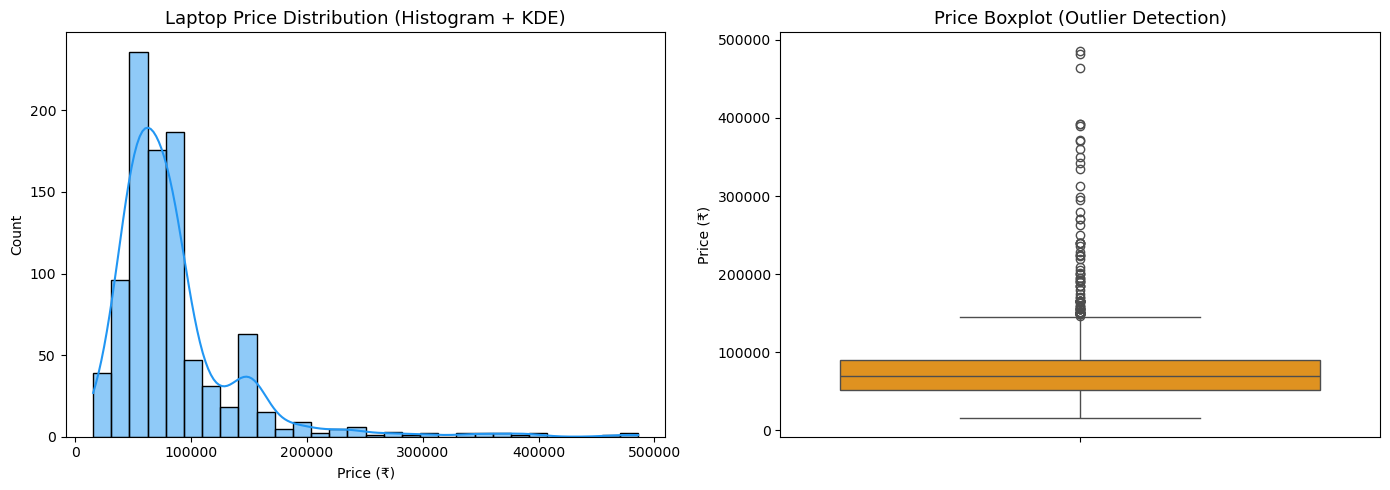

Mean   Price: ₹84,497
Median Price: ₹69,999
Std    Price: ₹55,691


In [93]:
# ── 5.1-A  Price Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=30, kde=True, color='#2196F3', ax=axes[0])
axes[0].set_title('Laptop Price Distribution (Histogram + KDE)', fontsize=13)
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

sns.boxplot(y=df['Price'], color='#FF9800', ax=axes[1])
axes[1].set_title('Price Boxplot (Outlier Detection)', fontsize=13)
axes[1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()

print(f"Mean   Price: ₹{df['Price'].mean():,.0f}")
print(f"Median Price: ₹{df['Price'].median():,.0f}")
print(f"Std    Price: ₹{df['Price'].std():,.0f}")

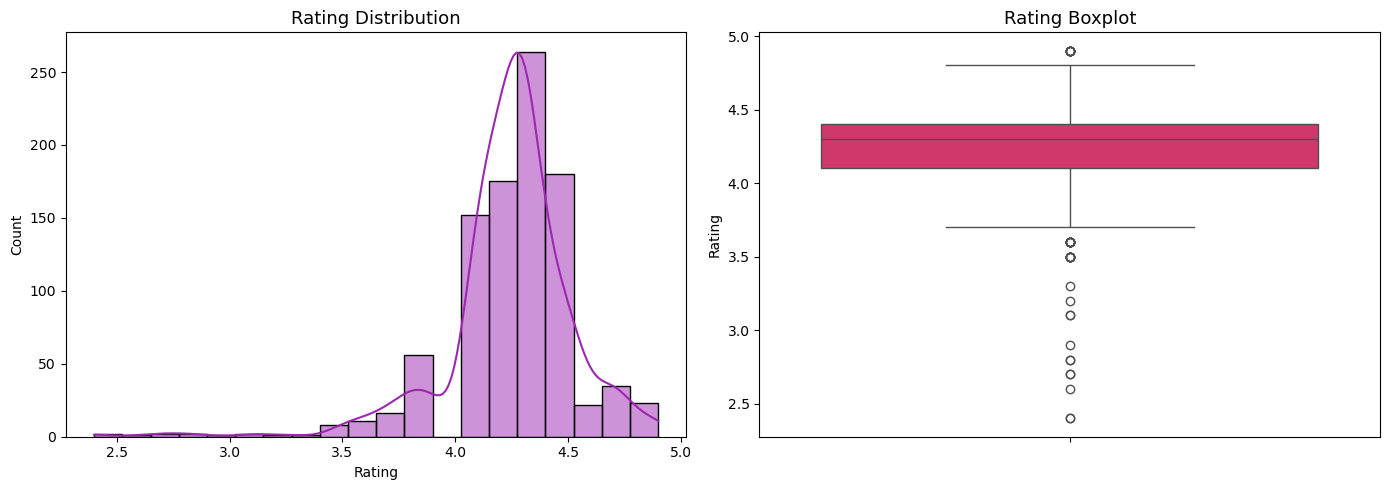

Rating range: 2.4 – 4.9
Mean rating : 4.24


In [94]:
# ── 5.1-B  Rating Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Rating'], bins=20, kde=True, color='#9C27B0', ax=axes[0])
axes[0].set_title('Rating Distribution', fontsize=13)
axes[0].set_xlabel('Rating')

sns.boxplot(y=df['Rating'], color='#E91E63', ax=axes[1])
axes[1].set_title('Rating Boxplot', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Rating range: {df['Rating'].min()} – {df['Rating'].max()}")
print(f"Mean rating : {df['Rating'].mean():.2f}")

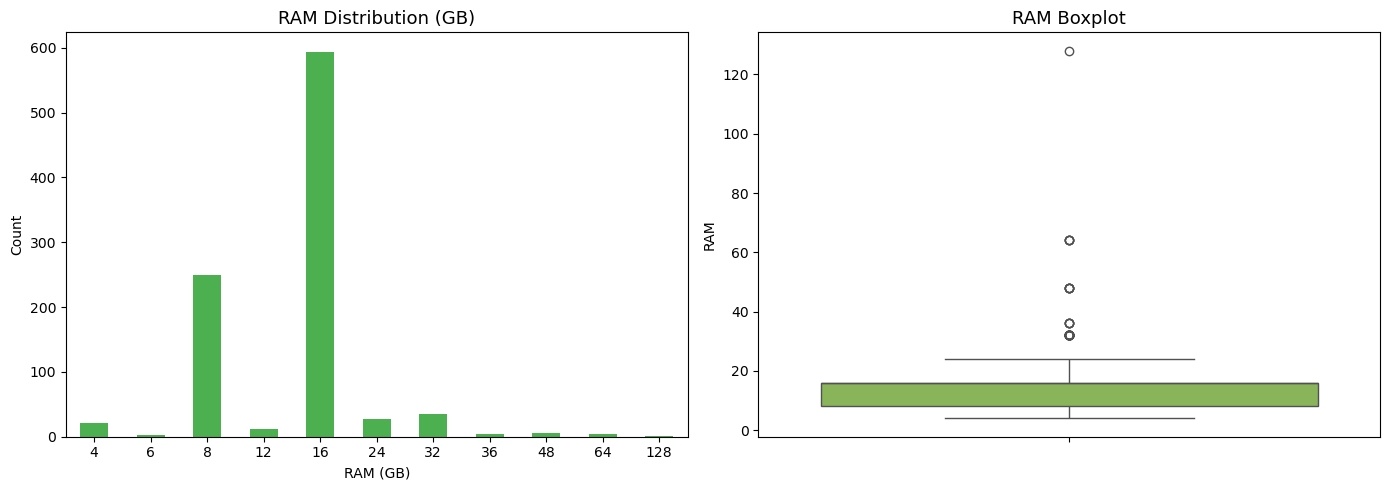

In [95]:
# ── 5.1-C  RAM Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['RAM'].value_counts().sort_index().plot(kind='bar', color='#4CAF50', ax=axes[0])
axes[0].set_title('RAM Distribution (GB)', fontsize=13)
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(y=df['RAM'], color='#8BC34A', ax=axes[1])
axes[1].set_title('RAM Boxplot', fontsize=13)

plt.tight_layout()
plt.show()

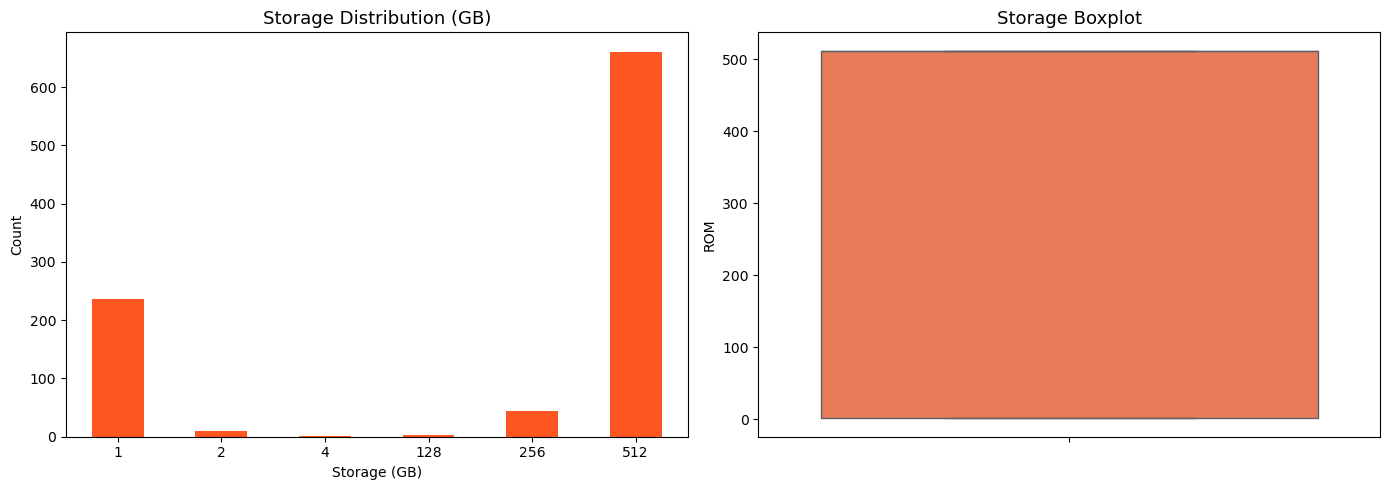

In [96]:
# ── 5.1-D  Storage (ROM) Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ROM'].value_counts().sort_index().plot(kind='bar', color='#FF5722', ax=axes[0])
axes[0].set_title('Storage Distribution (GB)', fontsize=13)
axes[0].set_xlabel('Storage (GB)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(y=df['ROM'], color='#FF7043', ax=axes[1])
axes[1].set_title('Storage Boxplot', fontsize=13)

plt.tight_layout()
plt.show()

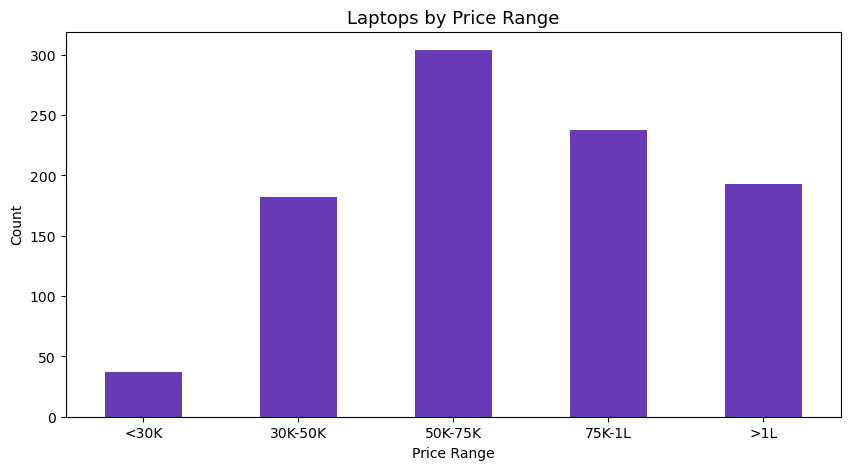

In [97]:
# ── 5.1-E  Price Range Buckets ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df['Price_Range'].value_counts().sort_index().plot(kind='bar', color='#673AB7', rot=0, ax=ax)
ax.set_title('Laptops by Price Range', fontsize=13)
ax.set_xlabel('Price Range')
ax.set_ylabel('Count')
plt.show()

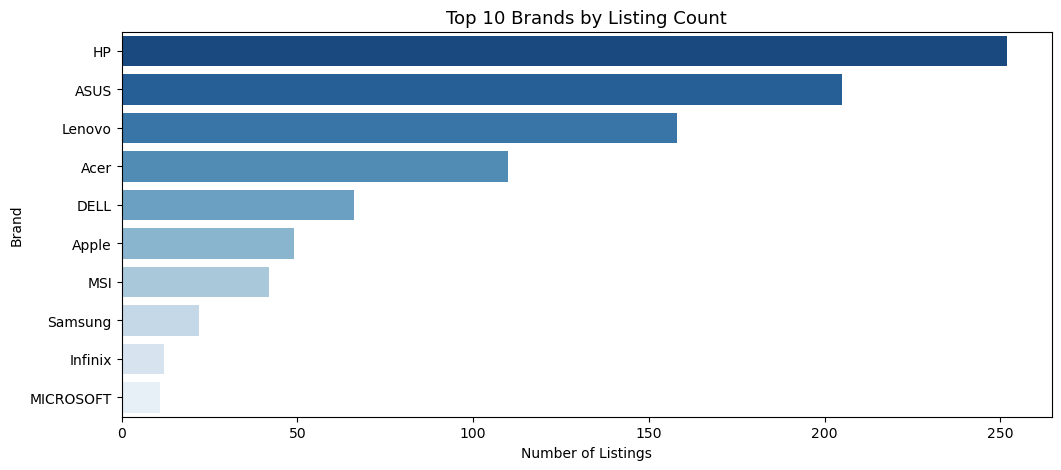

In [98]:
# ── 5.1-F Top Brands ────────────────────────────────────────────────────
top_brands = df['Brand'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Brands by Listing Count', fontsize=13)
ax.set_xlabel('Number of Listings')
plt.show()

### 5.2 Bivariate Analysis – Relationship between two variables

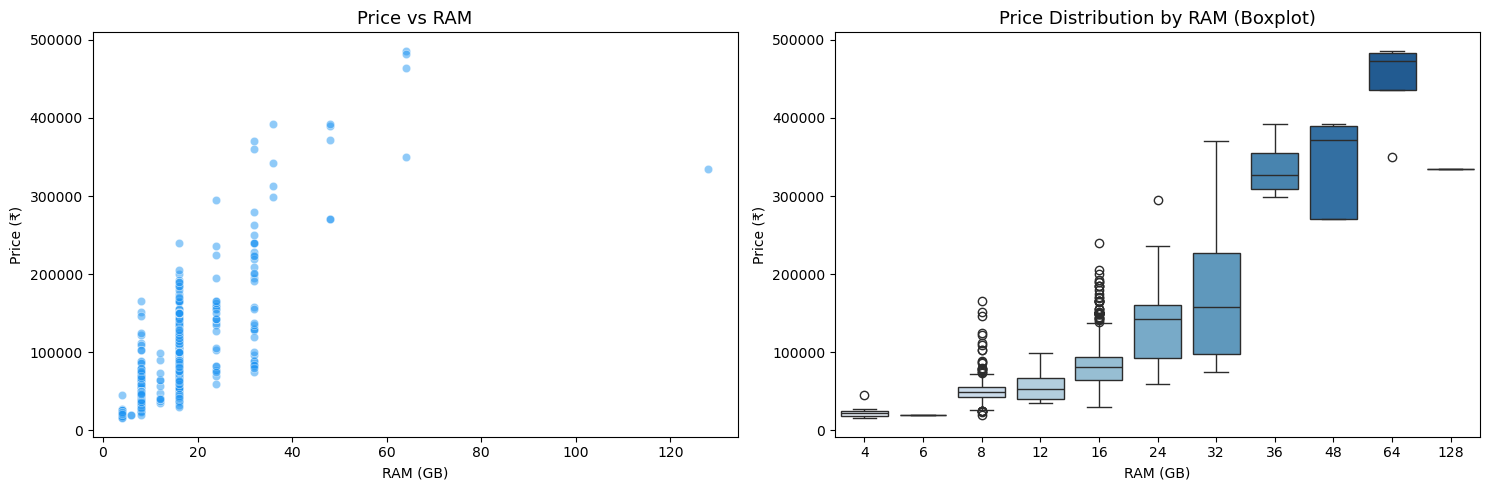

In [99]:
# ── 5.2-A  Price vs RAM ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='RAM', y='Price', alpha=0.5, color='#2196F3', ax=axes[0])
axes[0].set_title('Price vs RAM', fontsize=13)
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Price (₹)')

sns.boxplot(data=df, x='RAM', y='Price', palette='Blues', ax=axes[1])
axes[1].set_title('Price Distribution by RAM (Boxplot)', fontsize=13)
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()

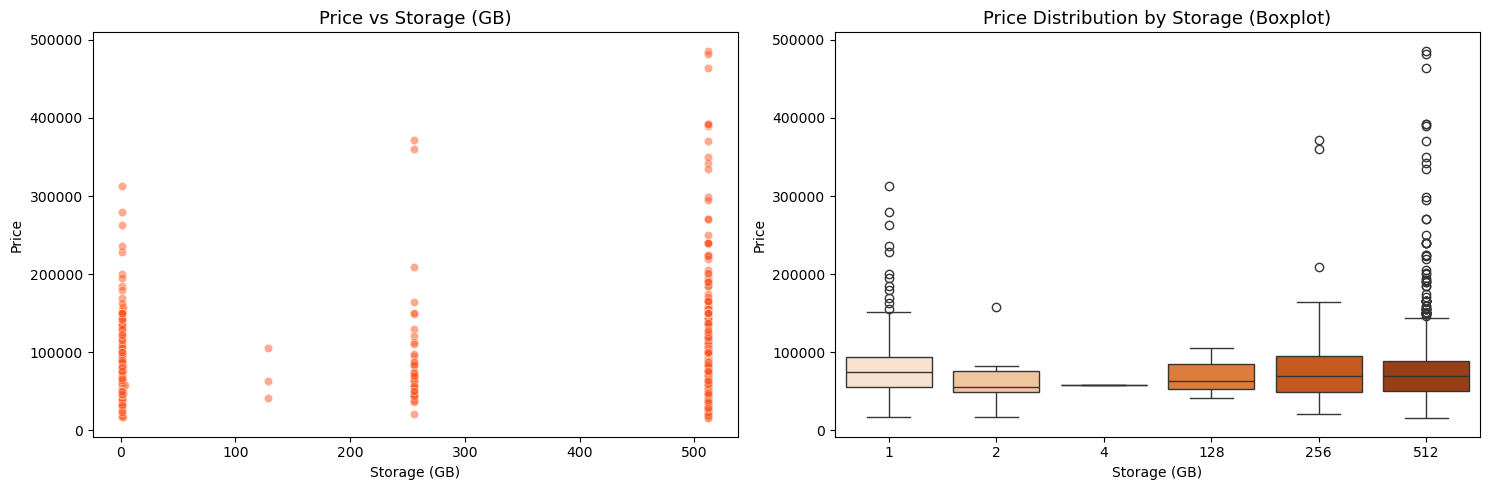

In [100]:
# ── 5.2-B  Price vs Storage (ROM) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='ROM', y='Price', alpha=0.5, color='#FF5722', ax=axes[0])
axes[0].set_title('Price vs Storage (GB)', fontsize=13)
axes[0].set_xlabel('Storage (GB)')

sns.boxplot(data=df, x='ROM', y='Price', palette='Oranges', ax=axes[1])
axes[1].set_title('Price Distribution by Storage (Boxplot)', fontsize=13)
axes[1].set_xlabel('Storage (GB)')

plt.tight_layout()
plt.show()

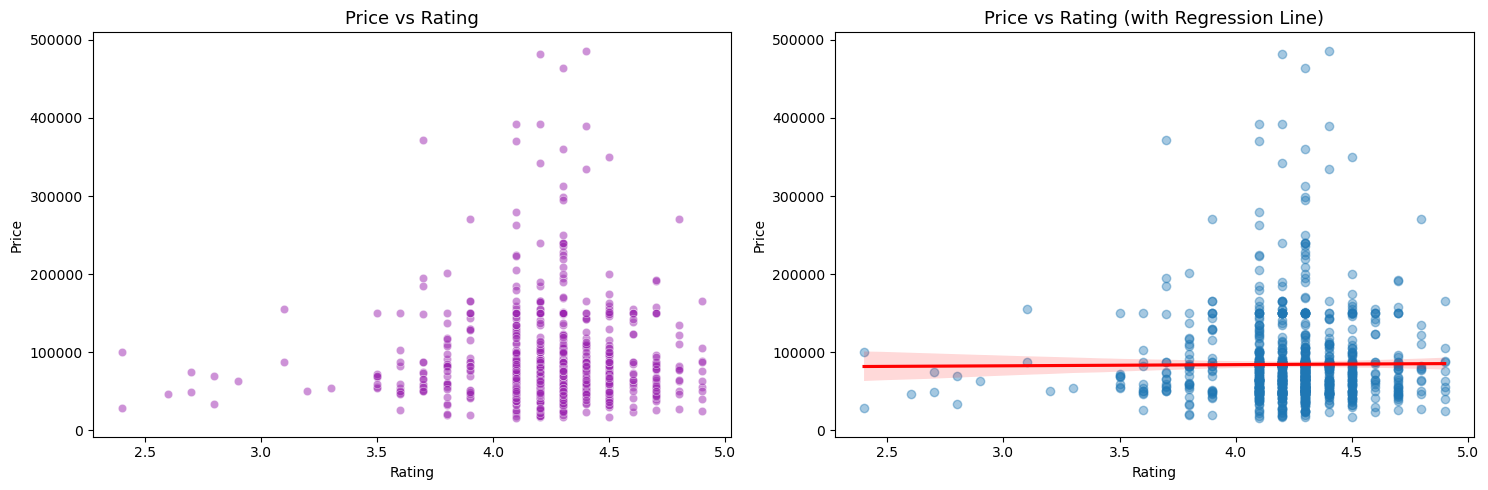

In [101]:
# ── 5.2-C  Price vs Rating ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='Rating', y='Price', alpha=0.5, color='#9C27B0', ax=axes[0])
axes[0].set_title('Price vs Rating', fontsize=13)

sns.regplot(data=df, x='Rating', y='Price', scatter_kws={'alpha':0.4},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Price vs Rating (with Regression Line)', fontsize=13)

plt.tight_layout()
plt.show()

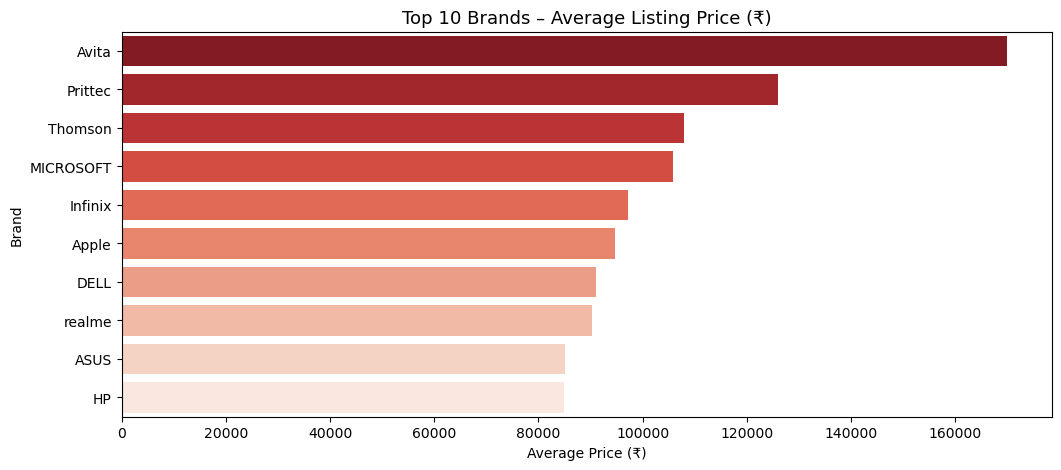

In [102]:
# ── 5.2-D  Average Price per Brand (Top 10) ───────────────────────────────
avg_price_brand = (
    df.groupby('Brand')['Price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=avg_price_brand.values, y=avg_price_brand.index, palette='Reds_r', ax=ax)
ax.set_title('Top 10 Brands – Average Listing Price (₹)', fontsize=13)
ax.set_xlabel('Average Price (₹)')
plt.show()

### 5.3 Multivariate Analysis

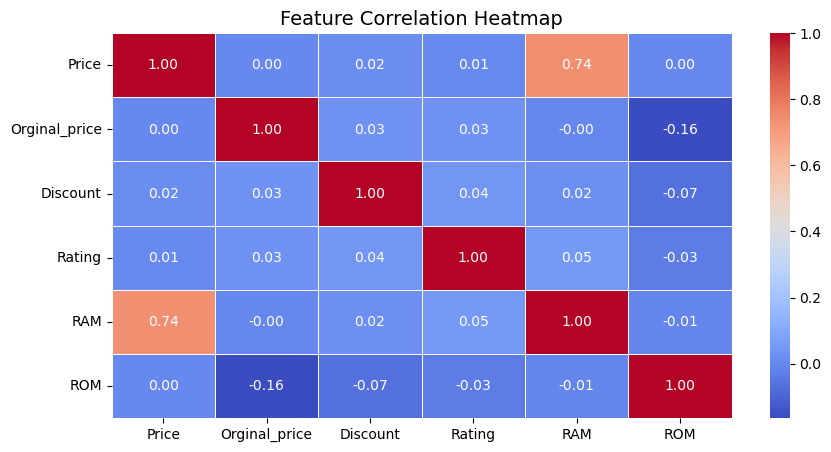

In [114]:
# ── 5.3-A  Correlation Heatmap ────────────────────────────────────────────
num_cols = ['Price', 'Orginal_price', 'Discount', 'Rating', 'RAM', 'ROM']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.show()

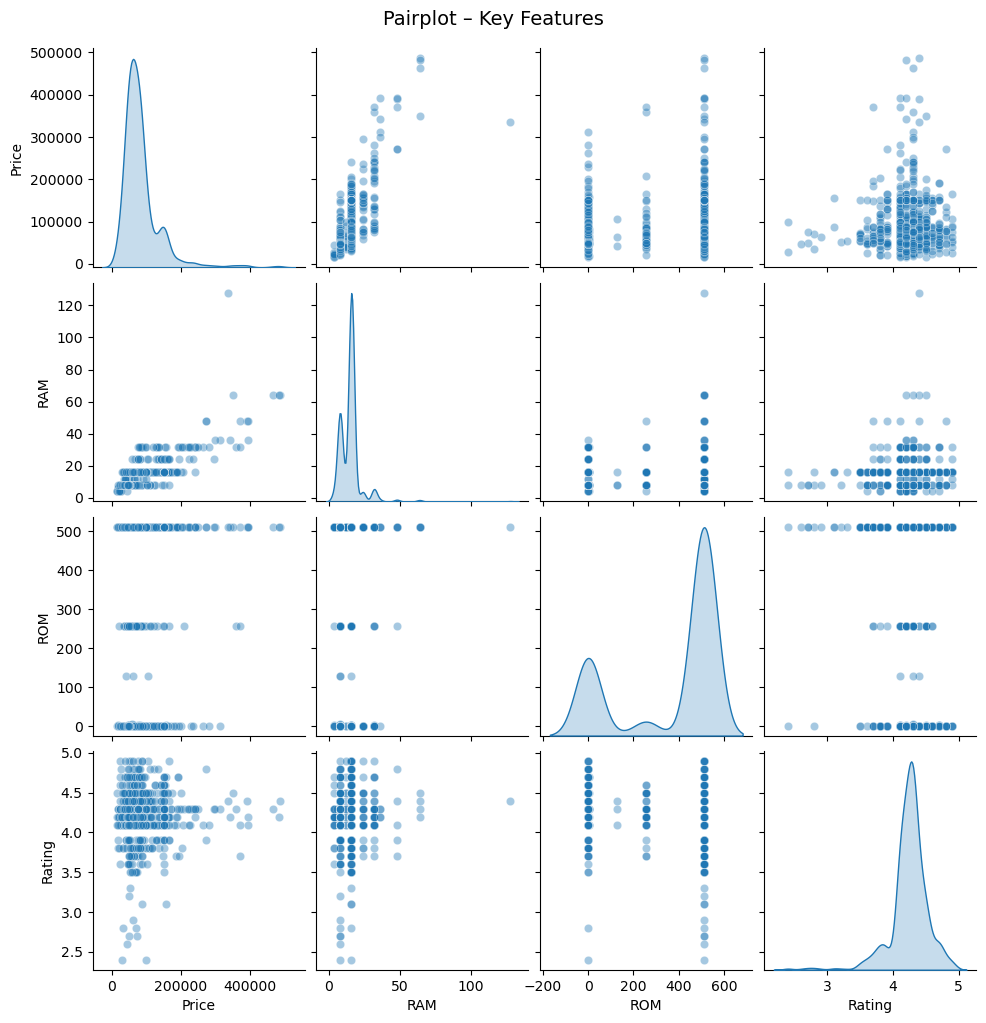

In [105]:
# ── 5.3-B  Pairplot (Price, RAM, ROM, Rating) ────────────────────────────
pair_cols = ['Price', 'RAM', 'ROM', 'Rating']
sns.pairplot(df[pair_cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot – Key Features', y=1.02, fontsize=14)
plt.show()

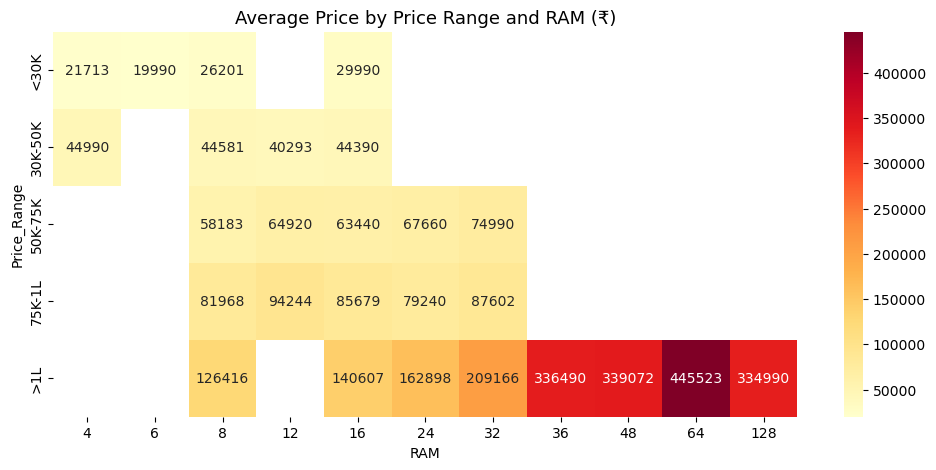

In [106]:
# ── 5.3-C  Price by RAM and Price Range (Heatmap-style pivot) ────────────
pivot = df.pivot_table(values='Price', index='Price_Range', columns='RAM', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Price by Price Range and RAM (₹)', fontsize=13)
plt.show()

---
## 6. Hypothesis Testing – Diagnostics Analysis (Why it happened)

EDA shows patterns. Hypothesis testing proves whether those patterns are real or random.

```
Without Hypothesis Testing          With Hypothesis Testing
──────────────────────────────────────────────────────────
"It looks like RAM affects price"   "RAM significantly affects price (p < 0.05)"
Opinion-based                        Data-driven
Weak storytelling                    Strong business justification
```

### Test 1: Does RAM significantly affect Price?

- **H₀:** RAM has no impact on laptop price
- **H₁:** Higher RAM increases price
- **Test:** Pearson Correlation + One-way ANOVA

In [107]:
# Pearson Correlation – RAM vs Price
corr_val, p_val = stats.pearsonr(df['RAM'].dropna(), df.loc[df['RAM'].notna(), 'Price'])
print(f'Correlation (RAM vs Price): {corr_val:.4f}')
print(f'p-value                   : {p_val:.6f}')

Correlation (RAM vs Price): 0.7369
p-value                   : 0.000000


In [108]:
if p_val < 0.05:
    print('Reject H₀ → RAM significantly affects price')
else:
    print('Fail to reject H₀ → No significant impact')

Reject H₀ → RAM significantly affects price


In [109]:
# One-way ANOVA: does price differ across RAM groups?
ram_groups = [group['Price'].values for _, group in df.groupby('RAM') if len(group) >= 5]
f_stat, p_anova = stats.f_oneway(*ram_groups)
print(f'ANOVA F-stat: {f_stat:.4f}')
print(f'ANOVA p-value: {p_anova:.6f}')
if p_anova < 0.05:
    print('Reject H₀ → Price significantly differs across RAM groups')
else:
    print('Fail to reject H₀')

ANOVA F-stat: 155.0784
ANOVA p-value: 0.000000
Reject H₀ → Price significantly differs across RAM groups


### Test 2: Does Rating significantly affect Price?

- **H₀:** Ratings do not affect price
- **H₁:** Higher-rated laptops are priced higher

In [110]:
corr_r, p_r = stats.pearsonr(df['Rating'].dropna(), df.loc[df['Rating'].notna(), 'Price'])
print(f'Correlation (Rating vs Price): {corr_r:.4f}')
print(f'p-value                      : {p_r:.6f}')

Correlation (Rating vs Price): 0.0077
p-value                      : 0.813426


In [111]:
if p_r < 0.05:
    print('Reject H₀ → Rating significantly affects price')
else:
    print('Fail to reject H₀ → No significant impact')

Fail to reject H₀ → No significant impact


### Test 3: Does Storage (ROM) significantly affect Price?

- **H₀:** Storage size has no impact on price
- **H₁:** Higher storage increases price

In [112]:
corr_s, p_s = stats.pearsonr(df['ROM'].dropna(), df.loc[df['ROM'].notna(), 'Price'])
print(f'Correlation (Storage vs Price): {corr_s:.4f}')
print(f'p-value                       : {p_s:.6f}')

if p_s < 0.05:
    print('Reject H₀ → Storage significantly affects price')
else:
    print('Fail to reject H₀ → No significant impact')

Correlation (Storage vs Price): 0.0025
p-value                       : 0.939524
Fail to reject H₀ → No significant impact


---
## 7. Conclusion – Final Business Insights (Answering Arjun's Questions)

==> **What I Observed**

Price is right-skewed – a few ultra-premium laptops pull the mean up.
Median price ≈ ₹55,000; mean is inflated by gaming/workstation laptops.
Most buyers buy in the ₹30K–₹75K range.

**Interpretation:** Mean price is misleading due to premium outliers.

==> **Business Insight for Arjun**

Paying a very high price is NOT the norm. Arjun should focus on the median price range, not premium extremes.

**RAM Analysis – What I Observed:**
- Most laptops: 8–16 GB RAM
- Price increases with RAM but plateaus after 16 GB
- **Insight:** 8 GB RAM is sufficient for everyday use; 16 GB is sweet spot. 32 GB = diminishing returns.

**Storage Analysis – What I Observed:**
- Majority of laptops have 512 GB SSD
- Higher storage → higher price, but weakens above 1 TB
- **Insight:** 512 GB SSD is sufficient. Blindly going higher adds cost without proportional value.

**Display Size – What I Observed:**
- Most laptops: 15.6 inch (highly standardized)
- Very little price variation due to display alone
- **Insight:** Display size is NOT a price differentiator.

**Rating – What I Observed:**
- Ratings cluster around 4.0–4.5 (low variability)
- Weak correlation with price
- **Insight:** Higher-rated laptops are NOT necessarily higher-priced. Ratings should not drive buying decisions.

**Correlation Heatmap Key Findings:**
- Stronger correlation: Price ↔ RAM, Price ↔ ROM
- Weak correlation: Price ↔ Rating, Price ↔ Display
- **Interpretation:** Technical specs drive price. Customer ratings are not pricing factors.

==> **Final Recommendation (Perfect Closing)**

For value-conscious buyers like Arjun:

| Feature | Recommendation |
|---------|----------------|
| **Price Range** | ₹40,000 – ₹65,000 |
| **RAM** | 8–16 GB (16 GB preferred for future-proofing) |
| **Storage** | 512 GB SSD minimum |
| **Rating** | Ignore small rating differences (4.1 vs 4.3 is negligible) |
| **Processor** | Intel Core i5/i7 Gen 12+ or AMD Ryzen 5/7 |

**Avoid** paying premium for specs beyond daily usage needs.
**RAM and Storage** are the real price drivers – optimize these.